In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:

clientes = pd.read_csv("../data/Clientes.csv")
categorias = pd.read_csv("../data/categorias.csv")
ventas = pd.read_csv("../data/Ventas.csv")
empleados = pd.read_csv("../data/empleados.csv")
productos = pd.read_csv("../data/productos.csv")
detalle_ventas = pd.read_csv("../data/detalle.csv")

In [7]:
ventas.head()

,ID_VENTA,FECHA,TOTAL,ID_CLIENTE,ID_EMPLEADO,PRODUCTO
0,1,10/05/26,6000,1,1,NaN
1,2,11/05/26,5000,2,2,NaN
2,3,12/05/26,1800,3,1,Monitor 24
3,4,15/05/26,2500,4,3,Monitor Curvo
4,5,18/05/26,450,5,4,Teclado Mecanico


In [8]:
productos.head()

,ID_PRODUCTO,NOMBRE,MARCA,PRECIO,STOCK,ID_CATEGORIA
0,1,Laptop Gamer,ASUS,8500,10,1
1,2,Mouse RGB,Logitech,250,30,2
2,3,Monitor 24,Samsung,1800,15,3
3,4,Teclado Mecanico,Redragon,450,25,2
4,5,Impresora EcoTank,Epson,2200,8,4


In [11]:
total_revenue = ventas["TOTAL"].sum()
total_revenue

np.int64(34800)

In [15]:
total_orders = ventas["ID_VENTA"].count()
total_orders

np.int64(12)

In [17]:
order_value = ventas["TOTAL"].mean()
order_value

np.float64(2900.0)

In [21]:
sales_employee = ventas.merge(empleados, on="ID_EMPLEADO")
sales_employee = sales_employee.groupby("NOMBRE")["TOTAL"].sum().reset_index()
sales_employee


,NOMBRE,TOTAL
0,Ana Morales,5850
1,Clara Mendez,1000
2,Dulce Canel,11000
3,Kevin Ortiz,10000
4,Maria Ortiz,6950


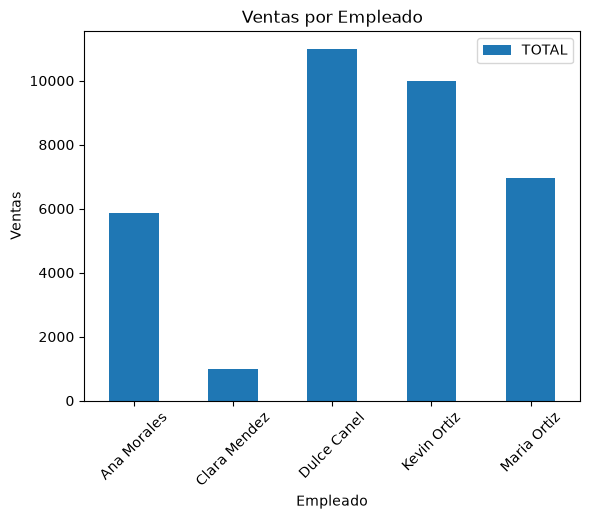

In [23]:
sales_employee.plot(x="NOMBRE", y="TOTAL", kind="bar")

plt.title("Ventas por Empleado")
plt.xlabel("Empleado")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()

In [26]:
productosVendidos = (
    detalle_ventas.merge(productos, on="ID_PRODUCTO")
    .groupby("NOMBRE")["CANTIDAD"].sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [27]:
productosCategoria = productos.merge (categorias, on="ID_CATEGORIA"
)

In [28]:
clientesTop = (
    ventas.merge(clientes, on="ID_CLIENTE")
    .groupby("NOMBRE")["TOTAL"].sum()
    .sort_values(ascending=False)
    .reset_index()
)

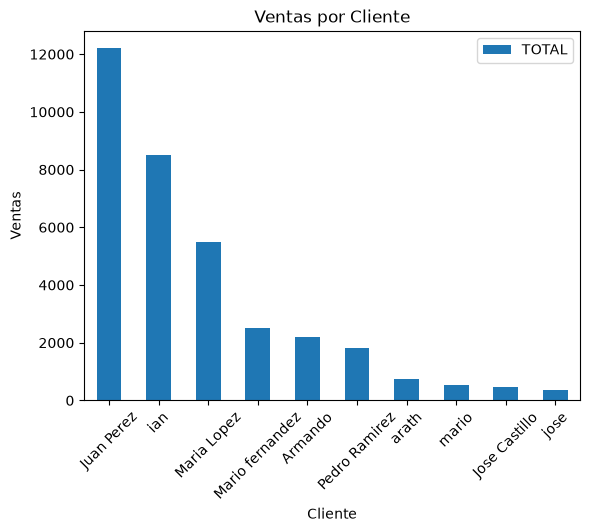

In [29]:
clientesTop.plot(x="NOMBRE", y="TOTAL", kind="bar")

plt.title("Ventas por Cliente")
plt.xlabel("Cliente")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()

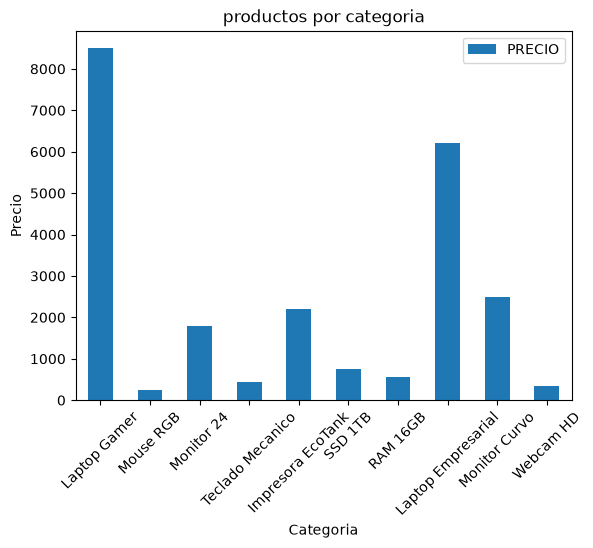

In [32]:
productosCategoria.plot(x="NOMBRE", y="PRECIO", kind="bar")
plt.title("productos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

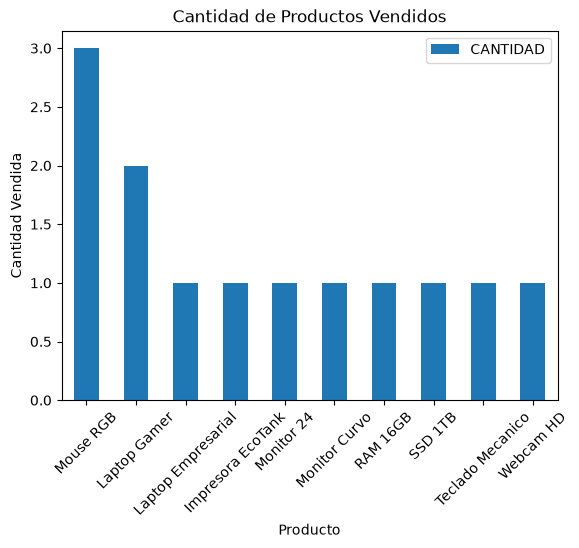

In [33]:
productosVendidos.plot(x="NOMBRE", y="CANTIDAD", kind="bar")
plt.title("Cantidad de Productos Vendidos") 
plt.xlabel("Producto")
plt.ylabel("Cantidad Vendida")
plt.xticks(rotation=45)
plt.show()

